In [1]:
import pandas as pd
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.shape)
df.info()
print(df.head())
print(df["Churn"].value_counts(normalize=True))  # ~73% No, ~27% Yes -> imbalanced!

(7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    


In [2]:
# TotalCharges is text with blank spaces; convert to number
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

df = df.drop("customerID", axis=1)          # ID has no predictive value
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [3]:
import sys
print(sys.executable)

d:\important\codec_intern_requirements\.venv\Scripts\python.exe


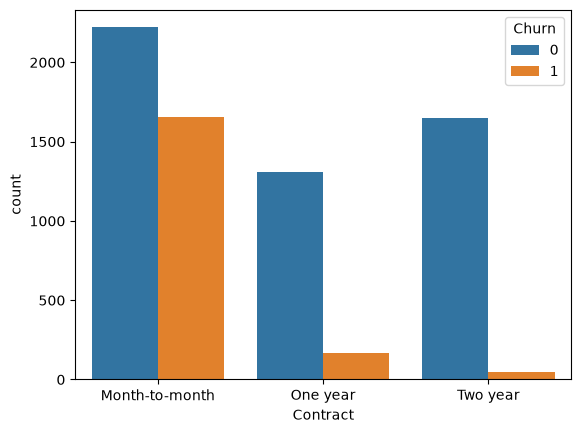

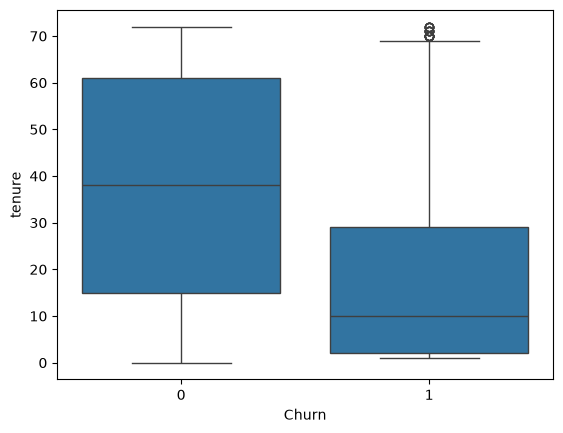

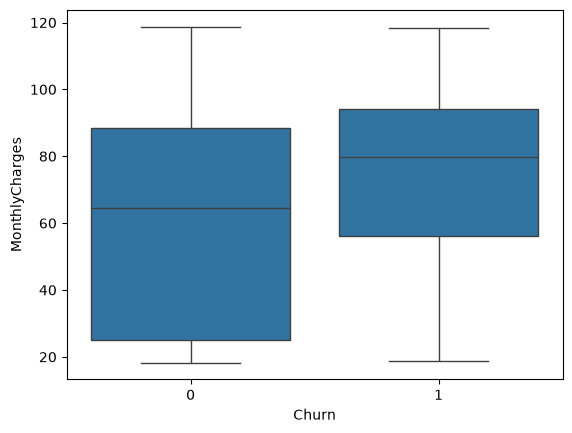

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x="Contract", hue="Churn", data=df); plt.show()
sns.boxplot(x="Churn", y="tenure", data=df); plt.show()
sns.boxplot(x="Churn", y="MonthlyCharges", data=df); plt.show()

In [5]:
df = pd.get_dummies(df, drop_first=True)

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

Handle imbalance with SMOTE (training data only)

In [7]:
from imblearn.over_sampling import SMOTE
X_train_sm, y_train_sm = SMOTE(random_state=42).fit_resample(X_train, y_train)
print(y_train_sm.value_counts())  # now balanced

Churn
0    4139
1    4139
Name: count, dtype: int64


Train models

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42),
}

for name, m in models.items():
    m.fit(X_train_sm, y_train_sm)

Evaluate properly 

In [9]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

for name, m in models.items():
    preds = m.predict(X_test)
    proba = m.predict_proba(X_test)[:, 1]
    print(f"\n=== {name} ===")
    print(classification_report(y_test, preds))
    print("AUC:", roc_auc_score(y_test, proba))


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.88      0.75      0.81      1035
           1       0.50      0.71      0.59       374

    accuracy                           0.74      1409
   macro avg       0.69      0.73      0.70      1409
weighted avg       0.78      0.74      0.75      1409

AUC: 0.8190989175643908

=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.92      0.65      0.76      1035
           1       0.46      0.84      0.60       374

    accuracy                           0.70      1409
   macro avg       0.69      0.74      0.68      1409
weighted avg       0.80      0.70      0.72      1409

AUC: 0.8240783797049782

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.86      0.81      0.83      1035
           1       0.54      0.63      0.58       374

    accuracy                           0.76      1409
   ma

Explain the results

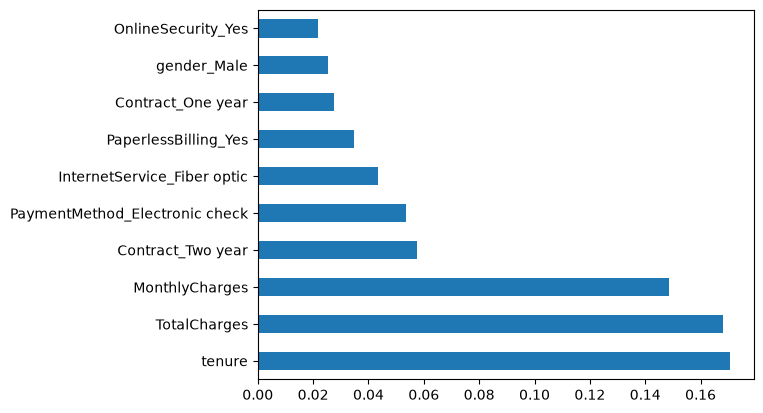

In [10]:
import numpy as np
rf = models["Random Forest"]
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
imp.head(10).plot(kind="barh"); plt.show()

Save the model and package the project

In [11]:
import joblib
joblib.dump(models["XGBoost"], "churn_model.pkl")

['churn_model.pkl']